In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
df=pd.read_csv('credit_risk_dataset.csv')

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(165)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
num_cols=df.select_dtypes(include=['int64','float64']).columns.drop('loan_status')
target=df['loan_status']

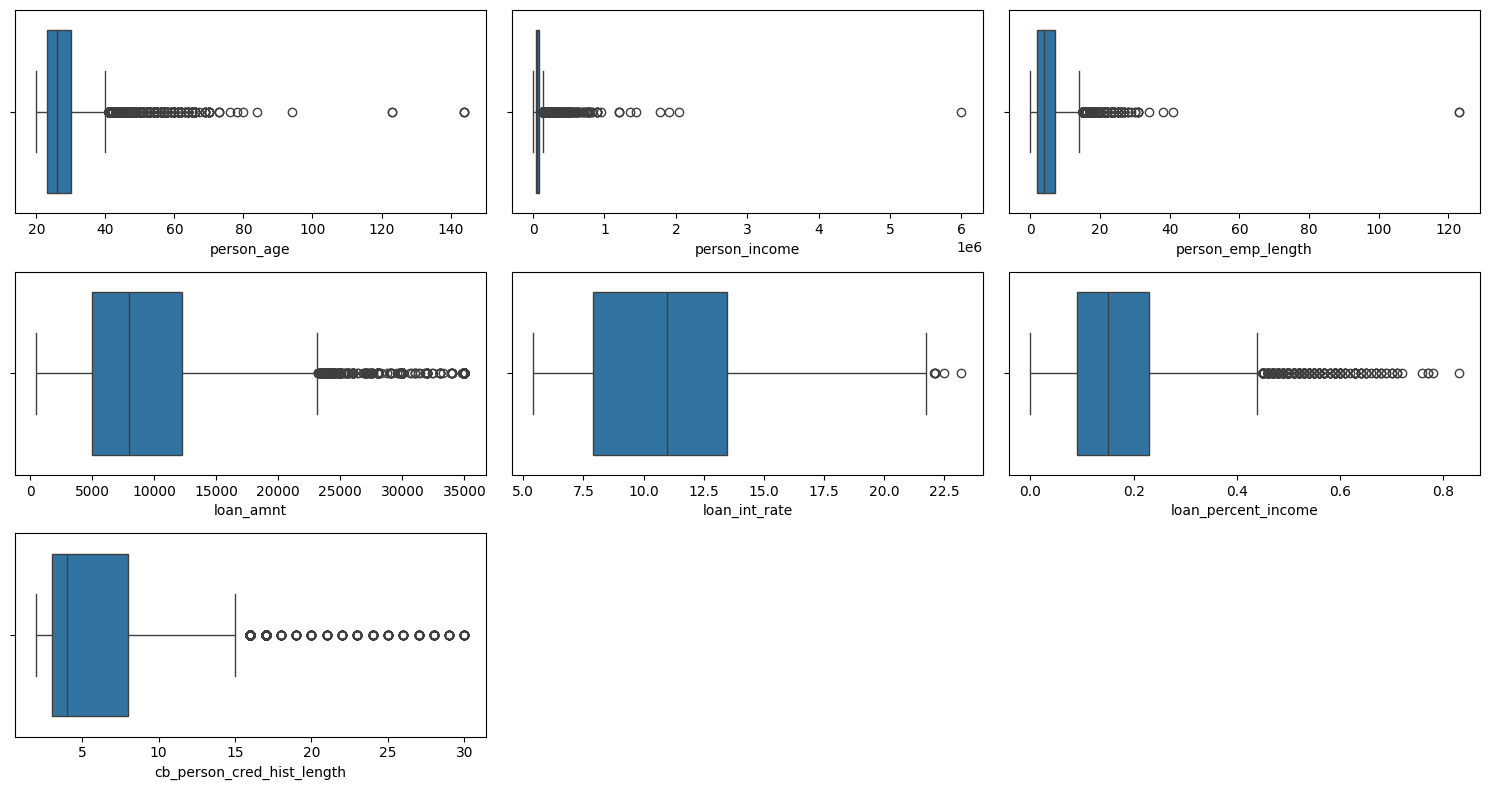

In [11]:
plt.figure(figsize=(15,8))
for i,j in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=df,x=df[j])
plt.tight_layout()
plt.show()

In [12]:
for j in num_cols:
    q1=df[j].quantile(0.25)
    q2=df[j].quantile(0.75)
    iqr=q2-q1
    lower=q1-(1.5*iqr)
    upper=q2+(1.5*iqr)
    df=df[(df[j]>=lower) & (df[j]<=upper)]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['loan_status']),df['loan_status'],test_size=0.2,random_state=42,stratify=df['loan_status'])

In [16]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

In [22]:
num_pipe=Pipeline([
    ('si',SimpleImputer(strategy='median')),
    ('ss',StandardScaler())
])

In [23]:
ctf=ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'),['person_home_ownership','loan_intent','cb_person_default_on_file']),
    ('oe',OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]),['loan_grade'])
],remainder='passthrough')

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score

In [25]:
models={
    'LogisticRegression':LogisticRegression(max_iter=10000,class_weight='balanced',random_state=42,solver='saga'),
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(n_estimators=50,n_jobs=-1,random_state=42),
    'XGBoost':XGBClassifier(random_state=42)
}

In [26]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessing',ctf),
        ('smote',SMOTE(random_state=42)),
        ('model',model)
    ])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    cv=cross_val_score(pipe,df.drop(columns=['loan_status']),df['loan_status'],cv=5,scoring='accuracy')
    print(f'{name}')
    print(f'accuracy:{acc:.4f}')
    print(f'CV Average:{cv.mean():.4f}')
    print(classification_report(y_test,y_pred))

LogisticRegression
accuracy:0.7900
CV Average:0.7748
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      3653
           1       0.49      0.75      0.59       923

    accuracy                           0.79      4576
   macro avg       0.71      0.77      0.72      4576
weighted avg       0.84      0.79      0.80      4576

DecisionTree
accuracy:0.8582
CV Average:0.8409
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3653
           1       0.64      0.69      0.66       923

    accuracy                           0.86      4576
   macro avg       0.78      0.79      0.79      4576
weighted avg       0.86      0.86      0.86      4576

RandomForest
accuracy:0.9226
CV Average:0.9127
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      3653
           1       0.93      0.67      0.78       923

    accuracy                       

In [27]:
pipe_xgb=Pipeline([
        ('preprocessing',ctf),
        ('smote',SMOTE(random_state=42)),
        ('xgb',XGBClassifier(random_state=42))
    ])

In [29]:
pipe_xgb.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred=pipe_xgb.predict(x_test)

In [32]:
accuracy_score(y_pred,y_test)

0.9263548951048951

In [33]:
import pickle

In [35]:
pickle.dump(pipe_xgb,open('model.pkl','wb'))